# Evaluation and Inference

In [13]:
import pandas as pd

columns = ["Model", "MAE", "MSE", "RMSE", "R2", "Best Params"]
results = pd.read_csv('all_model_results.csv', names=columns, index_col=False)

results.head(8)



,Model,MAE,MSE,RMSE,R2,Best Params
0,Linear Regression,0.245704,0.083183,0.288415,0.996113,Default
1,Lasso Regression,0.250842,0.086983,0.294929,0.995936,{'alpha': np.float64(0.01)}
2,Ridge Regression,0.245834,0.082978,0.288059,0.996123,{'alpha': np.float64(0.11)}
3,Decision Tree,0.333236,0.325708,0.570709,0.984782,"{'max_depth': 10, 'min_samples_leaf': 4, 'min_..."
4,Random Forest,0.336261,0.194572,0.441103,0.990909,"{'max_depth': 15, 'max_features': 'sqrt', 'min..."
5,XGBRegressor,0.299777,0.147200,0.383667,0.993122,"{'objective': 'reg:squarederror', 'base_score'..."
6,Stacking Regressor,0.245181,0.082874,0.287878,0.996128,"{'cv': 5, 'estimators': [('lr', LinearRegressi..."


In [22]:
def format_params(params):
    if isinstance(params, dict):
        return ', '.join(f"{k}={v}" for k, v in params.items())
    else:
        return str(params)

results['Best Params'] = results['Best Params'].apply(format_params)
# Show only Model and Best Params columns
display(results[['Model', 'Best Params']])


Model  \
0   Linear Regression   
1    Lasso Regression   
2    Ridge Regression   
3       Decision Tree   
4       Random Forest   
5        XGBRegressor   
6  Stacking Regressor   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

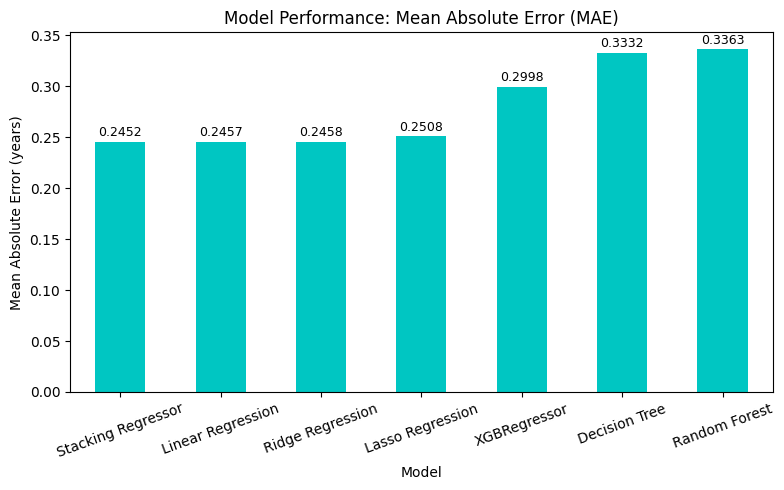

In [9]:
# import matplotlib.pyplot as plt

# results_sorted = results.sort_values(by='RMSE')
# ax = results_sorted.plot(x='Model', y=['RMSE', 'MAE', 'R2'], kind='bar', figsize=(7, 10))
# plt.title('Model Performance Comparison')
# plt.ylabel('Score')

# for idx, container in enumerate(ax.containers):
#        if idx == 2:  # R2 bars",
#            ax.bar_label(container, fmt='%.4f', fontsize=8, padding=2, rotation=45)
#        else:  # RMSE and MAE bars",
#            ax.bar_label(container, fmt='%.4f', fontsize=8, padding=2, rotation=90)

# plt.tight_layout()
# plt.show()

import matplotlib.pyplot as plt

results_sorted = results.sort_values(by='MAE')

ax = results_sorted.plot(
    x='Model',
    y='MAE',
    kind='bar',
    color='#00c6c2',
    legend=False,
    figsize=(8, 5)
)

plt.title('Model Performance: Mean Absolute Error (MAE)')
plt.ylabel('Mean Absolute Error (years)')
plt.xlabel('Model')
plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=9, padding=2)

plt.tight_layout()
plt.show()




/var/folders/3p/rr2nrbcj6j79v6mwqtwtdzbw0000gn/T/ipykernel_57041/2678189841.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_sorted['Model'], rotation=45, ha='right')


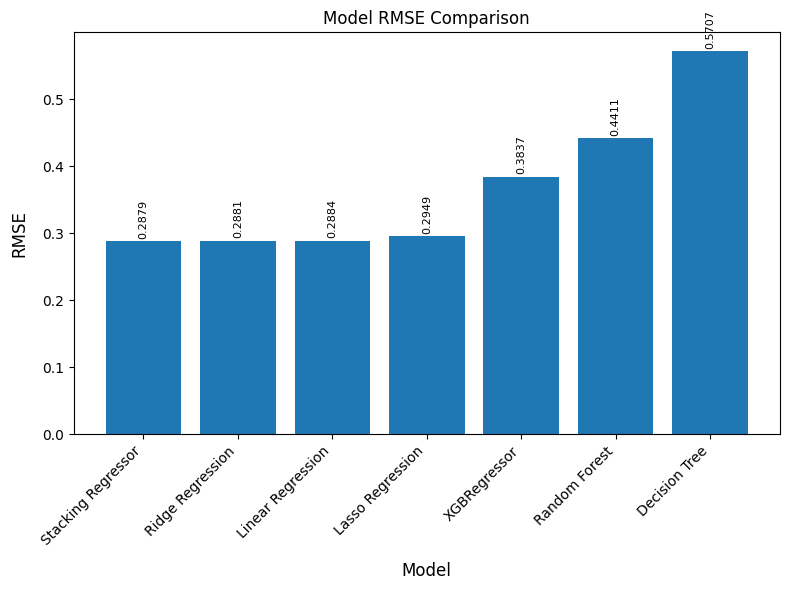

In [6]:
import matplotlib.pyplot as plt

results_sorted = results.sort_values(by='RMSE')
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(results_sorted['Model'], results_sorted['RMSE'])
ax.set_ylabel("RMSE", fontsize=12, labelpad=10)
ax.set_xlabel("Model", fontsize=12, labelpad=10)
ax.set_xticklabels(results_sorted['Model'], rotation=45, ha='right')
ax.set_title("Model RMSE Comparison")

# Add value labels to each bar
ax.bar_label(bars, fmt='%.4f', fontsize=8, padding=2, rotation=90)

plt.tight_layout()
plt.show()

## Import Required Libraries

In [4]:
import textstat
import pandas as pd
import joblib
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Example: Evaluating on a New Letter

In [5]:
test_text = """
What does a Family Court Adviser do?
I work for Cafcass to help children and families when the parents or carers haven’t been able to agree on what’s best for children and they ask the Family Court to help.
My job is to try to help families agree on where children live and who they spend time with. 
It’s important that I meet with you and understand your point of view so that I can help your family and the Judge to make the best and safest decisions for you.
I work hard to make sure that your voice is heard and that the court understands what you think about what I recommend to them about your future.
I am interested in how you feel and what you think should happen. It is important to help the court to make a decision about what is best and safe for you.
I will share my thinking and recommendations I write to the judge, with you. I will include what you say about it in my report. 
I am looking forward to meeting you. Please use my contact details in the box below to get (parent/carer) to let me know where you would like to meet [delete as appropriate].
We can meet:
•	at my office
•	at school	
•	where you live
•	somewhere else 
Please let me know if there are other ways you would like to stay in touch.
•	Video call
o	Teams
o	FaceTime
o	WhatsApp video call
•	Messaging
•	Phone call
•	Email
•	Text 
•	Letter
I am experienced in working with children so you can count on me to listen carefully to what you say and to take you seriously.
The reason why we are meeting
I am meeting with you to talk about your family and people who are important to you, what makes you happy and any other feelings you want to tell me about.
I also want to know about you and all the things that make you who you are.
When we speak together, I will try to understand what you think about what is going on in your family. If there is anything which makes you feel safe or unsafe when you are at home or with anyone in your family, then you should tell me please. This is because it is important that I can tell the judge about this and what I think will protect you and be safe for you. I hope that is ok. 
About you
When we meet it would be great to hear about these things (you might want to ask your parent/carer to write them down to help you remember). 
•	Who is important to you?
•	Where do you call home?
•	How does your family celebrate special occasions?
•	What types of food do you eat at home?
•	What is the best, most special thing about you and your family?
•	Is there anything that makes you feel worried that you want to talk to me about? 
•	What has changed in your life recently and how do you feel about that?
At the end of our meeting: 
I would like to ask you three questions and it would really help me if you are honest. I want to do my best for you so I need to hear from you what I have done well and what I could do better. I hope this is ok.
1.	Did I help you today? 
2.	What could I have done differently and better? 
3.	Looking at these faces, how do you feel after meeting me? 
Amend as appropriate for young children
Below is a link and a QR code for an online feedback form, this is just for you, so you can tell us how we have helped you and if there is anything we could have done better. 
If child is too young you could include: Your parent/carer has been sent a link to a feedback form within their letter and they can tell us how we may have helped you and if there is anything we could have done better.
You can always call our Hear to Listen service for children for free on 0808 175 3333. The friendly team will help you to tell us what you felt we did well and what we might be able to make even better.
"""

In [6]:
simplified_test_text = """
What does a Family Court Adviser do?
I work for Cafcass to help children and families when parents or carers can’t decide what is best for you, so they ask the Family Court for help.

My job is to help your family make choices about where you live and who you see.

It’s important that I meet you and listen to what you think, so I can help your family and the Judge choose what is best and safest for you.

I work hard to make sure the Judge hears what you say, and that the court knows what you think about what I tell them about your future.

I care about how you feel and what you want. I help the court decide what is best and safe for you.

I will show you what I think and what I write for the Judge. I will include what you say in my report.

I am looking forward to meeting you. Please ask your parent or carer to use my contact details below to let me know where you want to meet.

We can meet:
• at my office
• at your school
• at your home
• or somewhere else you like

Let me know if you want to stay in touch in a different way:
• Video call
o Teams
o FaceTime
o WhatsApp video call
• Messages
• Phone call
• Email
• Text
• Letter

I have worked with lots of children, so you can trust that I will listen to you and take you seriously.

The reason why we are meeting
I am meeting with you to talk about your family, who is important to you, what makes you happy, and any feelings you want to tell me about.

I also want to know about you and what makes you special.

When we talk, I want to understand what you think about what is happening in your family. If anything at home or with your family makes you feel safe or not safe, please tell me. I need to tell the Judge about this to help keep you safe. I hope that’s okay.

About you
When we meet, it would be great if you could tell me these things (you can ask your parent or carer to help you write them down):
• Who is important to you?
• Where is your home?
• How does your family celebrate special days?
• What food do you eat at home?
• What is the best thing about you and your family?
• Is there anything that worries you and you want to talk about?
• Has anything changed in your life lately, and how do you feel about it?

At the end of our meeting:
I want to ask you three questions, and I hope you will be honest. I want to do my best for you, so I need to know what I did well and what I can do better. I hope this is okay.

Did I help you today?

What could I have done better?

Look at these faces—how do you feel after meeting me?

Change if needed for younger children.

Below is a link and a QR code for a feedback form. This is just for you, so you can tell us how we helped and what we could do better.

If you are too young, your parent or carer has a link to a feedback form and they can tell us for you.

You can always call our Hear to Listen service for free at 0808 175 3333. The friendly team can help you tell us what we did well and what we could do better.
"""

## Feature Extraction for Inference

In [7]:
def extract_features(text):
    features = {}
    features['word_count'] = len(text.split())
    features['average_word_length'] = sum(len(word) for word in text.split()) / len(text.split())
    features['complex_word_count'] = sum(1 for word in text.split() if textstat.syllable_count(word) >= 3)
    features['percent_complex_words'] = features['complex_word_count'] / features['word_count']
    features['difficult_word_count'] = textstat.difficult_words(text)
    features['percent_difficult_words'] = features['difficult_word_count'] / features['word_count']
    features['sentence_count'] = textstat.sentence_count(text)
    features['syllables_per_word'] = textstat.syllable_count(text) / len(text.split())
    features['polysyllable_count'] = features['complex_word_count']
    features['flesch_reading_ease'] = textstat.flesch_reading_ease(text)
    features['automated_readability_index'] = textstat.automated_readability_index(text)
    features['dale_chall_readability_score'] = textstat.dale_chall_readability_score(text)
    features['difficult_words'] = features['difficult_word_count']
    features['linsear_write_formula'] = textstat.linsear_write_formula(text)
    features['spache_readability'] = textstat.spache_readability(text)
    features['reading_time'] = textstat.reading_time(text)
    return features

## Load the Trained Model and Predict

In [8]:
feature_columns = [
    'word_count', 'average_word_length', 'percent_complex_words', 'percent_difficult_words', 'sentence_count', 'syllables_per_word',
    'polysyllable_count', 'flesch_reading_ease', 'automated_readability_index',
    'dale_chall_readability_score', 'difficult_words', 'linsear_write_formula',
    'spache_readability', 'reading_time'
]

test_features = extract_features(test_text)
test_df = pd.DataFrame([test_features], columns=feature_columns)

## Load the Trained Model and Predict

### Decision Tree Model

In [9]:
model = joblib.load('../models/decision_tree_regressor.joblib')
decision_tree_predicted_age = model.predict(test_df)[0]
print(f"Predicted reading age: {decision_tree_predicted_age:.2f}")

target_age = 10
if decision_tree_predicted_age <= target_age:
    print("This letter is suitable for the target age.")
else:
    print("This letter is NOT suitable for the target age.")

Predicted reading age: 11.50
This letter is NOT suitable for the target age.


### Regression Random Forest

In [10]:
model = joblib.load('../models/random_forest_regressor.joblib')
random_forest_predicted_age = model.predict(test_df)[0]
print(f"Predicted reading age: {random_forest_predicted_age:.2f}")

target_age = 10
if random_forest_predicted_age <= target_age:
    print("This letter is suitable for the target age.")
else:
    print("This letter is NOT suitable for the target age.")

Predicted reading age: 10.90
This letter is NOT suitable for the target age.


### Lasso Regression

In [11]:
model = joblib.load('../models/lasso_regression.joblib')
lasso_predicted_age = model.predict(test_df)[0]
print(f"Predicted reading age: {lasso_predicted_age:.2f}")

target_age = 10
if lasso_predicted_age <= target_age:
    print("This letter is suitable for the target age.")
else:
    print("This letter is NOT suitable for the target age.")

Predicted reading age: 12.10
This letter is NOT suitable for the target age.


### Ridge Regression

In [12]:
model = joblib.load('../models/ridge_regression.joblib')
ridge_predicted_age = model.predict(test_df)[0]
print(f"Predicted reading age: {ridge_predicted_age:.2f}")

target_age = 10
if ridge_predicted_age <= target_age:
    print("This letter is suitable for the target age.")
else:
    print("This letter is NOT suitable for the target age.")

Predicted reading age: 12.05
This letter is NOT suitable for the target age.


### Linear Regression

In [13]:
model = joblib.load('../models/linear_regression.joblib')
linear_predicted_age = model.predict(test_df)[0]
print(f"Predicted reading age: {linear_predicted_age:.2f}")

target_age = 10
if linear_predicted_age <= target_age:
    print("This letter is suitable for the target age.")
else:
    print("This letter is NOT suitable for the target age.")

Predicted reading age: 12.05
This letter is NOT suitable for the target age.


### Stacking Regression

In [14]:
model = joblib.load('../models/stacking_regressor.joblib')
stacking_predicted_age = model.predict(test_df)[0]
print(f"Predicted reading age: {stacking_predicted_age:.2f}")

target_age = 10
if stacking_predicted_age <= target_age:
    print("This letter is suitable for the target age.")
else:
    print("This letter is NOT suitable for the target age.")

Predicted reading age: 12.04
This letter is NOT suitable for the target age.


### XGB Boost

In [15]:
model = joblib.load('../models/xgb_model.joblib')
xgb_predicted_age = model.predict(test_df)[0]
print(f"Predicted reading age: {xgb_predicted_age:.2f}")

target_age = 10
if xgb_predicted_age <= target_age:
    print("This letter is suitable for the target age.")
else:
    print("This letter is NOT suitable for the target age.")

Predicted reading age: 11.80
This letter is NOT suitable for the target age.


## Calculate Flesch-Kincaid Score for External Comparison

In [16]:
fk_score = textstat.flesch_kincaid_grade(test_text)
print(f"Flesch-Kincaid grade: {fk_score:.2f}")

Flesch-Kincaid grade: 7.02


## Compare Model Prediction to UK-Adjusted Flesch-Kincaid Score

In [17]:

fk_score = textstat.flesch_kincaid_grade(test_text)
fk_uk_reading_age = fk_score + 5
print(f"Decision Tree Model predicted UK reading age: {decision_tree_predicted_age:.2f}")
print(f"Random Forest Model predicted UK reading age: {random_forest_predicted_age:.2f}")
print(f"Lasso Regression Model predicted UK reading age: {lasso_predicted_age:.2f}")
print(f"Ridge Regression Model predicted UK reading age: {ridge_predicted_age:.2f}")
print(f"Linear Regression Model predicted UK reading age: {linear_predicted_age:.2f}")
print(f"Stacking Regression Model predicted UK reading age: {stacking_predicted_age:.2f}")
print(f"XGBoost Model predicted UK reading age: {xgb_predicted_age:.2f}")

print(f"Flesch-Kincaid estimated UK reading age: {fk_uk_reading_age:.2f}")

Decision Tree Model predicted UK reading age: 11.50
Random Forest Model predicted UK reading age: 10.90
Lasso Regression Model predicted UK reading age: 12.10
Ridge Regression Model predicted UK reading age: 12.05
Linear Regression Model predicted UK reading age: 12.05
Stacking Regression Model predicted UK reading age: 12.04
XGBoost Model predicted UK reading age: 11.80
Flesch-Kincaid estimated UK reading age: 12.02


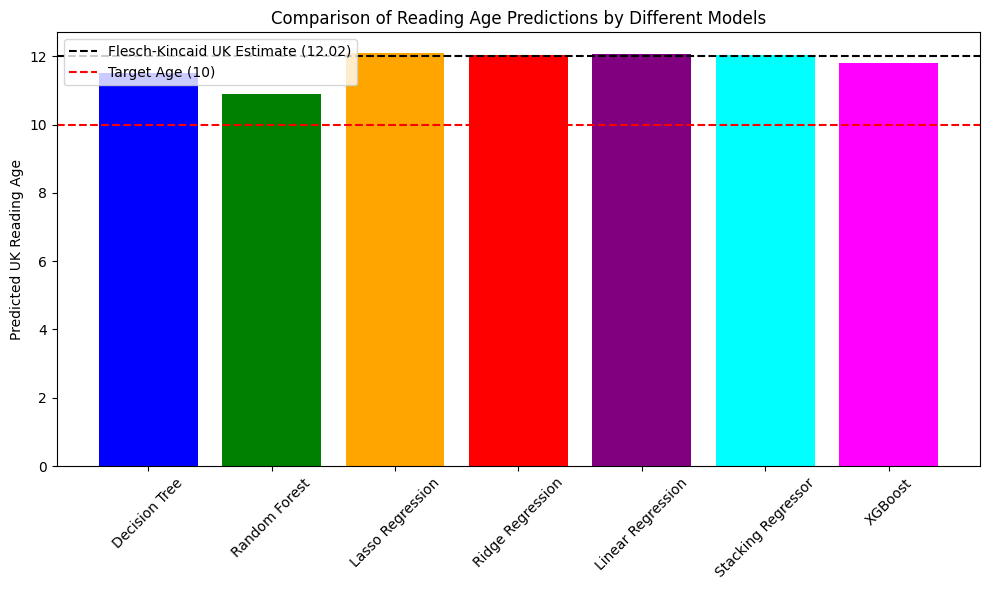

In [18]:
# Graph to show best model
import matplotlib.pyplot as plt
target_age = 10
model_names = ['Decision Tree', 'Random Forest', 'Lasso Regression', 'Ridge Regression', 'Linear Regression', 'Stacking Regressor', 'XGBoost']
predicted_ages = [
    decision_tree_predicted_age,
    random_forest_predicted_age,
    lasso_predicted_age,
    ridge_predicted_age,
    linear_predicted_age,
    stacking_predicted_age,
    xgb_predicted_age
]

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, predicted_ages, color=['blue', 'green', 'orange', 'red', 'purple', 'cyan', 'magenta'])

# Flesch-Kincaid UK estimate line
plt.axhline(y=fk_uk_reading_age, color='black', linestyle='--', label=f'Flesch-Kincaid UK Estimate ({fk_uk_reading_age:.2f})')

# Target age line (e.g., 10)
plt.axhline(y=target_age, color='red', linestyle='--', label=f'Target Age ({target_age})')

plt.ylabel('Predicted UK Reading Age')
plt.title('Comparison of Reading Age Predictions by Different Models')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
def extract_features(text):
    features = {}
    features['word_count'] = len(text.split())
    features['average_word_length'] = sum(len(word) for word in text.split()) / len(text.split())
    features['complex_word_count'] = sum(1 for word in text.split() if textstat.syllable_count(word) >= 3)
    features['percent_complex_words'] = features['complex_word_count'] / features['word_count']
    features['difficult_word_count'] = textstat.difficult_words(text)
    features['percent_difficult_words'] = features['difficult_word_count'] / features['word_count']
    features['sentence_count'] = textstat.sentence_count(text)
    features['syllables_per_word'] = textstat.syllable_count(text) / len(text.split())
    features['polysyllable_count'] = features['complex_word_count']
    features['flesch_reading_ease'] = textstat.flesch_reading_ease(text)
    features['automated_readability_index'] = textstat.automated_readability_index(text)
    features['dale_chall_readability_score'] = textstat.dale_chall_readability_score(text)
    features['difficult_words'] = features['difficult_word_count']
    features['linsear_write_formula'] = textstat.linsear_write_formula(text)
    features['spache_readability'] = textstat.spache_readability(text)
    features['reading_time'] = textstat.reading_time(text)
    return features

In [20]:
feature_columns = [
    'word_count', 'average_word_length', 'percent_complex_words', 'percent_difficult_words', 'sentence_count', 'syllables_per_word',
    'polysyllable_count', 'flesch_reading_ease', 'automated_readability_index',
    'dale_chall_readability_score', 'difficult_words', 'linsear_write_formula',
    'spache_readability', 'reading_time'
]

simplified_test_features = extract_features(simplified_test_text)
simplified_test_df = pd.DataFrame([simplified_test_features], columns=feature_columns)

In [21]:
model = joblib.load('../models/decision_tree_regressor.joblib')
decision_tree_predicted_age = model.predict(simplified_test_df)[0]
print(f"Predicted reading age: {decision_tree_predicted_age:.2f}")

target_age = 10
if decision_tree_predicted_age <= target_age:
    print("This letter is suitable for the target age.")
else:
    print("This letter is NOT suitable for the target age.")

Predicted reading age: 9.25
This letter is suitable for the target age.


In [22]:
model = joblib.load('../models/random_forest_regressor.joblib')
random_forest_predicted_age = model.predict(simplified_test_df)[0]
print(f"Predicted reading age: {random_forest_predicted_age:.2f}")

target_age = 10
if random_forest_predicted_age <= target_age:
    print("This letter is suitable for the target age.")
else:
    print("This letter is NOT suitable for the target age.")

Predicted reading age: 9.62
This letter is suitable for the target age.


In [23]:
model = joblib.load('../models/lasso_regression.joblib')
lasso_predicted_age = model.predict(simplified_test_df)[0]
print(f"Predicted reading age: {lasso_predicted_age:.2f}")

target_age = 10
if lasso_predicted_age <= target_age:
    print("This letter is suitable for the target age.")
else:
    print("This letter is NOT suitable for the target age.")

Predicted reading age: 10.15
This letter is NOT suitable for the target age.


In [24]:
model = joblib.load('../models/ridge_regression.joblib')
ridge_predicted_age = model.predict(simplified_test_df)[0]
print(f"Predicted reading age: {ridge_predicted_age:.2f}")

target_age = 10
if ridge_predicted_age <= target_age:
    print("This letter is suitable for the target age.")
else:
    print("This letter is NOT suitable for the target age.")

Predicted reading age: 10.15
This letter is NOT suitable for the target age.


In [25]:
model = joblib.load('../models/linear_regression.joblib')
linear_predicted_age = model.predict(simplified_test_df)[0]
print(f"Predicted reading age: {linear_predicted_age:.2f}")

target_age = 10
if linear_predicted_age <= target_age:
    print("This letter is suitable for the target age.")
else:
    print("This letter is NOT suitable for the target age.")

Predicted reading age: 10.15
This letter is NOT suitable for the target age.


In [26]:
model = joblib.load('../models/stacking_regressor.joblib')
stacking_predicted_age = model.predict(simplified_test_df)[0]
print(f"Predicted reading age: {stacking_predicted_age:.2f}")

target_age = 10
if stacking_predicted_age <= target_age:
    print("This letter is suitable for the target age.")
else:
    print("This letter is NOT suitable for the target age.")

Predicted reading age: 10.13
This letter is NOT suitable for the target age.


In [27]:
model = joblib.load('../models/xgb_model.joblib')
xgb_predicted_age = model.predict(simplified_test_df)[0]
print(f"Predicted reading age: {xgb_predicted_age:.2f}")

target_age = 10
if xgb_predicted_age <= target_age:
    print("This letter is suitable for the target age.")
else:
    print("This letter is NOT suitable for the target age.")

Predicted reading age: 9.72
This letter is suitable for the target age.


In [28]:
fk_score = textstat.flesch_kincaid_grade(simplified_test_text)
print(f"Flesch-Kincaid grade: {fk_score:.2f}")

Flesch-Kincaid grade: 5.10


In [29]:

fk_score = textstat.flesch_kincaid_grade(simplified_test_text)
fk_uk_reading_age = fk_score + 5
print(f"Decision Tree Model predicted UK reading age: {decision_tree_predicted_age:.2f}")
print(f"Random Forest Model predicted UK reading age: {random_forest_predicted_age:.2f}")
print(f"Lasso Regression Model predicted UK reading age: {lasso_predicted_age:.2f}")
print(f"Ridge Regression Model predicted UK reading age: {ridge_predicted_age:.2f}")
print(f"Linear Regression Model predicted UK reading age: {linear_predicted_age:.2f}")
print(f"Stacking Regression Model predicted UK reading age: {stacking_predicted_age:.2f}")
print(f"XGBoost Model predicted UK reading age: {xgb_predicted_age:.2f}")

print(f"Flesch-Kincaid estimated UK reading age: {fk_uk_reading_age:.2f}")

Decision Tree Model predicted UK reading age: 9.25
Random Forest Model predicted UK reading age: 9.62
Lasso Regression Model predicted UK reading age: 10.15
Ridge Regression Model predicted UK reading age: 10.15
Linear Regression Model predicted UK reading age: 10.15
Stacking Regression Model predicted UK reading age: 10.13
XGBoost Model predicted UK reading age: 9.72
Flesch-Kincaid estimated UK reading age: 10.10


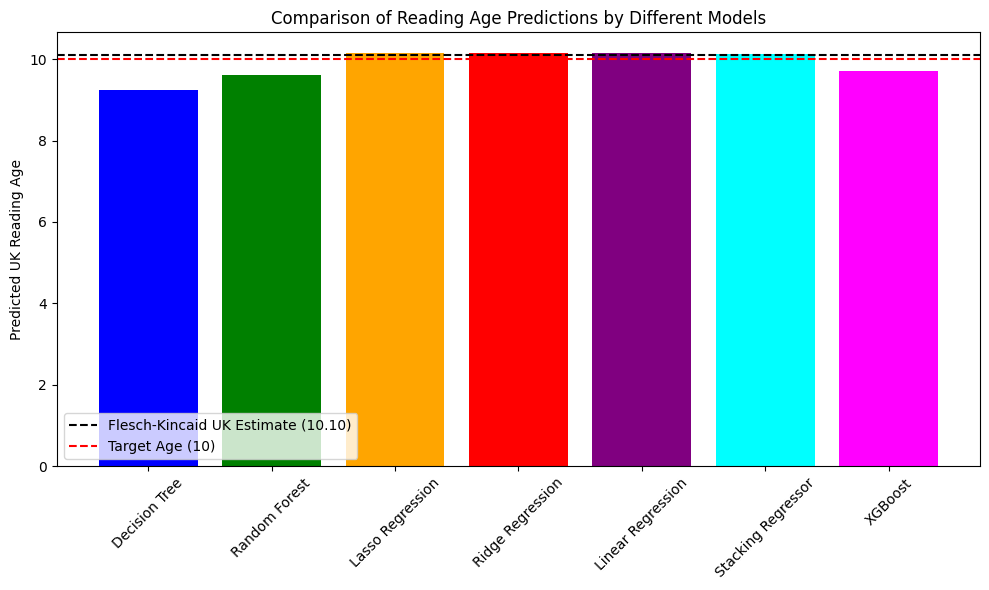

In [30]:
# Graph to show best model
import matplotlib.pyplot as plt
target_age = 10
model_names = ['Decision Tree', 'Random Forest', 'Lasso Regression', 'Ridge Regression', 'Linear Regression', 'Stacking Regressor', 'XGBoost']
predicted_ages = [
    decision_tree_predicted_age,
    random_forest_predicted_age,
    lasso_predicted_age,
    ridge_predicted_age,
    linear_predicted_age,
    stacking_predicted_age,
    xgb_predicted_age
]
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, predicted_ages, color=['blue', 'green', 'orange', 'red', 'purple', 'cyan', 'magenta'])

# Flesch-Kincaid UK estimate line
plt.axhline(y=fk_uk_reading_age, color='black', linestyle='--', label=f'Flesch-Kincaid UK Estimate ({fk_uk_reading_age:.2f})')

# Target age line (e.g., 10)
plt.axhline(y=target_age, color='red', linestyle='--', label=f'Target Age ({target_age})')

plt.ylabel('Predicted UK Reading Age')
plt.title('Comparison of Reading Age Predictions by Different Models')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Final Evaluation: Comparing Different Model Configurations

In [31]:
# df = pd.read_csv('../feature_engineering.csv')

# feature_columns = [
#     'word_count', 'average_word_length', 'percent_complex_words', 'percent_difficult_words', 'sentence_count', 'syllables_per_word',
#     'polysyllable_count', 'flesch_reading_ease', 'automated_readability_index',
#     'dale_chall_readability_score', 'difficult_words', 'linsear_write_formula',
#     'spache_readability', 'reading_time'
# ]

# X = df[feature_columns]
# y = df['fk_estimated_uk_age_num']

# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=456
# )

# def evaluate_depth(depth=None):
#     if depth is not None:
#         model = DecisionTreeRegressor(max_depth=depth, random_state=42)
#     else:
#         model = DecisionTreeRegressor(random_state=42)
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     mae = mean_absolute_error(y_test, y_pred)
#     mse = mean_squared_error(y_test, y_pred)
#     rmse = np.sqrt(mse)
#     r2 = r2_score(y_test, y_pred)
#     return mae, mse, rmse, r2

# # Evaluate: untuned, depth=3, and depth=10
# mae0, mse0, rmse0, r20 = evaluate_depth()        # no max_depth (fully grown)
# mae3, mse3, rmse3, r23 = evaluate_depth(3)
# mae10, mse10, rmse10, r210 = evaluate_depth(10)

# print(f"Untuned   - MAE: {mae0:.3f}, MSE: {mse0:.3f}, RMSE: {rmse0:.3f}, R²: {r20:.3f}")
# print(f"Depth 3   - MAE: {mae3:.3f}, MSE: {mse3:.3f}, RMSE: {rmse3:.3f}, R²: {r23:.3f}")
# print(f"Depth 10  - MAE: {mae10:.3f}, MSE: {mse10:.3f}, RMSE: {rmse10:.3f}, R²: {r210:.3f}")

# import pandas as pd
# import joblib
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# feature_columns = [
#     'word_count', 'average_word_length', 'percent_complex_words', 'percent_difficult_words', 'sentence_count', 'syllables_per_word',
#     'polysyllable_count', 'flesch_reading_ease', 'automated_readability_index',
#     'dale_chall_readability_score', 'difficult_words', 'linsear_write_formula',
#     'spache_readability', 'reading_time'
# ]

# df = pd.read_csv('../feature_engineering.csv')
# X = df[feature_columns]
# y = df['fk_estimated_uk_age_num']

# # Load the final, cross-validated Random Forest model
# model = joblib.load('../../models/random_forest_regressor.joblib')

# # Predict and evaluate on the full dataset or a test set as appropriate
# y_pred = model.predict(X)

# mae = mean_absolute_error(y, y_pred)
# mse = mean_squared_error(y, y_pred)
# rmse = mse ** 0.5
# r2 = r2_score(y, y_pred)

# print(f"Final Model - MAE: {mae:.3f}, MSE: {mse:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}")